In [1]:
import os
import json
import numpy as np
import torch
import joblib

# Paths (update if different in your project)
BASE = "/Volumes/Dev/Project2/YogaPoseFusion/backend"
PROCESSED = os.path.join(BASE, "data", "processed")
MODELS = os.path.join(BASE, "models")

CSV_PATH = os.path.join(PROCESSED, "pose_features_spectral.csv")  # same as in trains_model.ipynb
SCALER_PATH = os.path.join(MODELS, "scaler.pkl")                   # saved in YogaPoseDataset
MODEL_PATH = os.path.join(MODELS, "pose_classifier_v4_fold1.pt")   # or best fold
POSE_MAPPING_PATH = os.path.join(PROCESSED, "pose_mapping.json")

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# ---------------------------------------------------------------------
# Load class mapping (class_name -> index) and invert to index -> name
# ---------------------------------------------------------------------
with open(POSE_MAPPING_PATH, "r") as f:
    pose_mapping = json.load(f)           # {class_name: index}
idx_to_class = {v: k for k, v in pose_mapping.items()}  # {index: class_name}

# ---------------------------------------------------------------------
# Model definition (must EXACTLY match YogaPoseFusionNet in trains_model.ipynb)
# ---------------------------------------------------------------------
class ResidualBlock(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(dim, dim),
            torch.nn.BatchNorm1d(dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
        )

    def forward(self, x):
        return x + self.layer(x)


class YogaPoseFusionNet(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            ResidualBlock(1024),

            torch.nn.Linear(1024, 512),
            torch.nn.BatchNorm1d(512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            ResidualBlock(512),

            torch.nn.Linear(512, 256),
            torch.nn.BatchNorm1d(256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),

            torch.nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)

# ---------------------------------------------------------------------
# Helper: load scaler + build model with correct input_dim/num_classes
# ---------------------------------------------------------------------
def load_model_and_scaler():
    # Load scaler fitted during training
    scaler = joblib.load(SCALER_PATH)  # StandardScaler on combined features [file:2]

    # Infer input_dim from CSV (same file used in training)
    import pandas as pd
    df = pd.read_csv(CSV_PATH)
    X = df.drop(columns=["label"]).values  # same as in trains_model.ipynb [file:2]
    input_dim = X.shape[1]

    num_classes = len(idx_to_class)

    model = YogaPoseFusionNet(input_dim=input_dim, num_classes=num_classes).to(DEVICE)
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    return model, scaler, input_dim

model, scaler, input_dim = load_model_and_scaler()

# ---------------------------------------------------------------------
# Batch inference on precomputed test features (spectral + keypoints)
# ---------------------------------------------------------------------
def infer_on_test_split():
    # If you have a pre-built test features CSV (same structure as train CSV):
    import pandas as pd
    TEST_CSV = os.path.join(PROCESSED, "test_features_spectral.csv")  # create analogously if needed
    df_test = pd.read_csv(TEST_CSV)
    X_test = df_test.values.astype(np.float32)

    # Scale with training scaler
    X_test_scaled = scaler.transform(X_test)

    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        outputs = model(X_test_tensor)
        pred_indices = torch.argmax(outputs, dim=1).cpu().numpy()
        pred_classes = [idx_to_class[int(idx)] for idx in pred_indices]

    for i, cls in enumerate(pred_classes):
        print(f"Sample {i}: Predicted class = {cls}")

# ---------------------------------------------------------------------
# Single-sample inference: expects a raw feature vector of length input_dim
# (already built as [keypoints + spectral] and in same order as training)
# ---------------------------------------------------------------------
def predict_single(X_new_raw: np.ndarray):
    assert X_new_raw.shape[0] == input_dim, f"Expected feature dim {input_dim}, got {X_new_raw.shape[0]}"

    # Scale with training scaler
    X_new_scaled = scaler.transform(X_new_raw.reshape(1, -1))

    X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        output = model(X_new_tensor)
        pred_idx = int(torch.argmax(output, dim=1).item())
        pred_class = idx_to_class[pred_idx]
    return pred_class

# Example usage for a random dummy vector (replace with real [keypoints+spectral] features)
if __name__ == "__main__":
    # Dummy example
    X_new = np.random.rand(input_dim).astype(np.float32)
    print("Predicted class for dummy input:", predict_single(X_new))


/Volumes/Dev/anaconda3/envs/ds/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:1098: RuntimeWarning: overflow encountered in divide
  X /= self.scale_


Predicted class for dummy input: Supta_Virasana_Vajrasana


/Volumes/Dev/anaconda3/envs/poseperfect/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


X_test shape: (1556, 137)
Scaler expects n_features_in_: 137
y_true shape: (1556,)
pred_indices shape: (1556,)
Test Accuracy: 0.8091
Precision: 0.7991 | Recall: 0.8069 | F1: 0.7930

Classification Report:
                                                                           precision    recall  f1-score   support

                                                       Akarna_Dhanurasana       0.89      1.00      0.94         8
                              Bharadvajas_Twist_pose_or_Bharadvajasana_I_       0.44      0.89      0.59         9
                                         Boat_Pose_or_Paripurna_Navasana_       0.89      0.96      0.92        25
                                     Bound_Angle_Pose_or_Baddha_Konasana_       0.87      0.77      0.82        26
                                                 Bow_Pose_or_Dhanurasana_       0.95      1.00      0.97        19
                                 Bridge_Pose_or_Setu_Bandha_Sarvangasana_       1.00      0.81      0.89

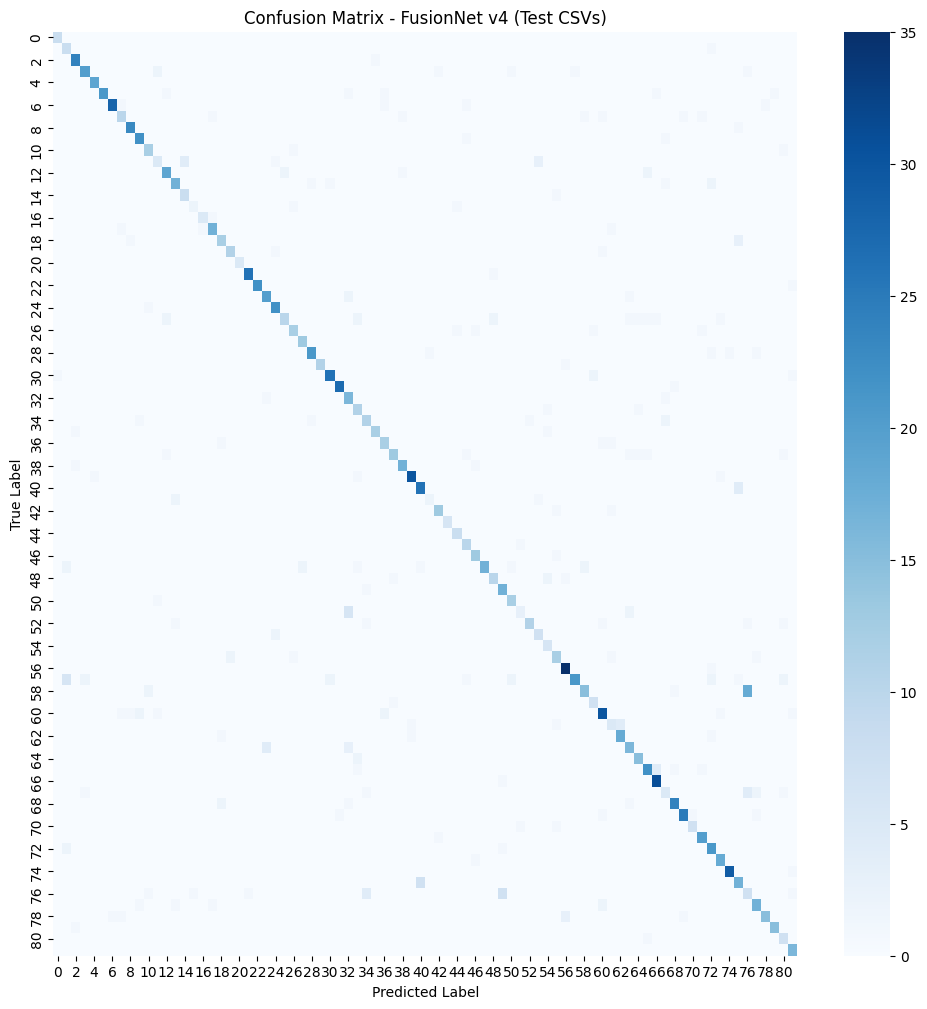

In [3]:
import os
import json
import numpy as np
import pandas as pd
import torch
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------- Paths -----------------
BASE = "/Volumes/Dev/Project2/YogaPoseFusion/backend"
PROCESSED = os.path.join(BASE, "data", "processed")
MODELS = os.path.join(BASE, "models")

POSE_MAPPING_PATH = os.path.join(PROCESSED, "pose_mapping.json")
SCALER_PATH = os.path.join(MODELS, "scaler.pkl")
MODEL_PATH = os.path.join(MODELS, "pose_classifier_v4_fold1.pt")

TEST_KEY_CSV = os.path.join(PROCESSED, "test_keypoints.csv")
TEST_SPEC_CSV = os.path.join(PROCESSED, "test_spectral.csv")
TEST_META_CSV = os.path.join(PROCESSED, "test_metadata.csv")

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

# ----------------- Mapping -----------------
with open(POSE_MAPPING_PATH, "r") as f:
    pose_mapping = json.load(f)           # {class_name: index}
idx_to_class = {v: k for k, v in pose_mapping.items()}
num_classes = len(idx_to_class)

# ----------------- Model definition (v4) -----------------
class ResidualBlock(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.layer = torch.nn.Sequential(
            torch.nn.Linear(dim, dim),
            torch.nn.BatchNorm1d(dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
        )

    def forward(self, x):
        return x + self.layer(x)


class YogaPoseFusionNet(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 1024),
            torch.nn.BatchNorm1d(1024),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            ResidualBlock(1024),

            torch.nn.Linear(1024, 512),
            torch.nn.BatchNorm1d(512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            ResidualBlock(512),

            torch.nn.Linear(512, 256),
            torch.nn.BatchNorm1d(256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),

            torch.nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)

# ----------------- Load scaler & TEST features -----------------
scaler = joblib.load(SCALER_PATH)  # fitted on combined TRAIN features [file:2]

df_key_test = pd.read_csv(TEST_KEY_CSV)     # only keypoint columns [file:3]
df_spec_test = pd.read_csv(TEST_SPEC_CSV)   # only spectral columns [file:3]
df_meta_test = pd.read_csv(TEST_META_CSV)   # has label_index [file:3]

# Sanity: all shapes must match
assert len(df_key_test) == len(df_spec_test) == len(df_meta_test), \
    (len(df_key_test), len(df_spec_test), len(df_meta_test))

# Build fusion features in the SAME way as training: np.hstack([X_key, X_spec]) [file:2]
X_key_test = df_key_test.values.astype(np.float32)
X_spec_test = df_spec_test.values.astype(np.float32)
X_test = np.hstack([X_key_test, X_spec_test]).astype(np.float32)

print("X_test shape:", X_test.shape)
print("Scaler expects n_features_in_:", scaler.n_features_in_)

# Scale with training scaler
X_test_scaled = scaler.transform(X_test)

input_dim = X_test_scaled.shape[1]

# True labels from metadata (label_index column written in preprocessing) [file:3]
y_true = df_meta_test["label_index"].values.astype(int)
print("y_true shape:", y_true.shape)

# ----------------- Load model -----------------
model = YogaPoseFusionNet(input_dim=input_dim, num_classes=num_classes).to(DEVICE)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

# ----------------- Inference -----------------
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    outputs = model(X_test_tensor)
    pred_indices = torch.argmax(outputs, dim=1).cpu().numpy()

print("pred_indices shape:", pred_indices.shape)

# ----------------- Metrics -----------------
acc = accuracy_score(y_true, pred_indices)
print(f"Test Accuracy: {acc:.4f}")

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, pred_indices, average="macro", zero_division=0
)
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        pred_indices,
        target_names=[idx_to_class[i] for i in range(num_classes)],
        zero_division=0,
    )
)

# ----------------- Confusion matrix -----------------
cm = confusion_matrix(y_true, pred_indices)
plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - FusionNet v4 (Test CSVs)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
